In [4]:
import pypsa

network1 = pypsa.Network("../results/128_wAT_entsoe_MA/networks/base_s_128_elec_.nc")
network2 = pypsa.Network("pypsa_nc/austria_network.nc")


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network austria_network.nc has buses, lines


In [5]:
network2.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_name,country
Bus,,,,,,,,,,,,,,
19001.0,110.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
39001.0,380.0,1.0,16.434483,48.182819,AC,,1.0,0.0,inf,PQ,,,Simmering,Austria
19002.0,110.0,1.0,16.475635,48.156029,AC,,1.0,0.0,inf,PQ,,,Kaiserebersdorf,Austria
13001.0,110.0,5.0,16.507006,48.135957,AC,,1.0,0.0,inf,PQ,,,Schwechat,Austria
19003.0,110.0,1.0,16.420303,48.123892,AC,,1.0,0.0,inf,PQ,,,Wien Suedost,Austria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14041.0,110.0,1.0,14.052108,48.083252,AC,,1.0,0.0,inf,PQ,,,Sattledt,Austria
14043.0,110.0,1.0,14.330044,47.678294,AC,,1.0,0.0,inf,PQ,,,Pyhrn,Austria
24141.0,220.0,1.0,14.247019,47.903419,AC,,1.0,0.0,inf,PQ,,,Molln,Austria


In [6]:
network1.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_lv,substation_off,location,country
Bus,,,,,,,,,,,,,,,,
AL0 0,380.0,,19.845426,41.518089,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AL
AT0 0,380.0,,13.899802,48.104391,AC,,1.0,0.0,inf,Slack,AT0 0 CCGT,,1.0,1.0,,AT
AT0 1,380.0,,16.311236,48.205145,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 10,380.0,,15.737397,48.268775,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 11,380.0,,14.711651,48.130419,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SI0 0 battery,1.0,,15.043369,46.170477,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SI0 0,SI
SK0 0 battery,1.0,,19.227945,48.601176,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SK0 0,SK
UA0 0 battery,1.0,,25.078479,49.592749,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,UA0 0,UA


## Plot before

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



(<matplotlib.collections.PatchCollection at 0x76c312ca3a70>,
 <matplotlib.collections.LineCollection at 0x76c312cbf140>)

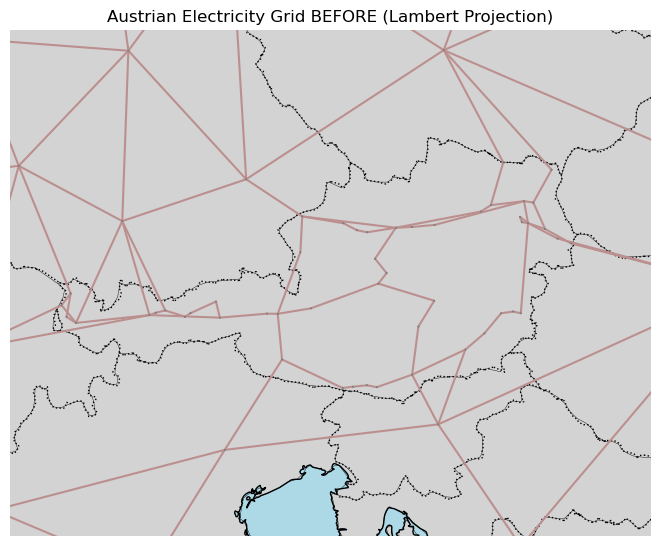

In [7]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# Define Lambert Conformal projection centered over Austria
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)

# Create custom line colors for cross-border lines
#line_colors = n.lines["cross_border"].map({True: "red", False: "blue"})

projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]
figsize = (8.27, 11.69)  # Size of the figure (A4)

# Create the plot with the projection
fig, ax = plt.subplots(
    figsize=figsize,
    subplot_kw={"projection": projection}
)

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

import cartopy.feature as cfeature
# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network
network1.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid BEFORE (Lambert Projection)",
    boundaries=[9,18,45,50]
)

In [8]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Assume: `network1` is the PyPSA-Eur network and `network2` is the detailed Austrian network

# 1. Extract bus DataFrames
buses1 = network1.buses.copy()
buses2 = network2.buses.copy()

# # 2. Filter only Austrian buses from network1
# # Assume Austrian buses have ISO code in name or coordinates within bounding box
# austria_bbox = {
#     "minx": 9.5,
#     "maxx": 17.0,
#     "miny": 46.0,
#     "maxy": 49.1,
# }
# mask_at1 = (
#     (buses1['x'] >= austria_bbox["minx"]) & (buses1['x'] <= austria_bbox["maxx"]) &
#     (buses1['y'] >= austria_bbox["miny"]) & (buses1['y'] <= austria_bbox["maxy"])
# )
# austrian_buses1 = buses1[mask_at1]

# Step 2: Filter Austrian buses in network1
austrian_buses1 = buses1[buses1['country'].isin(['AT', 'Austria'])]

# 3. Build KDTree from network2 bus coordinates
tree = cKDTree(buses2[['x', 'y']].values)

# 4. Query nearest neighbors for each Austrian bus in network1
dists, indices = tree.query(austrian_buses1[['x', 'y']].values)

# 5. Update coordinates in network1
updated_coords = buses2.iloc[indices][['x', 'y']].values
buses1.loc[austrian_buses1.index, ['x', 'y']] = updated_coords

# 6. Assign back to network1
network1.buses.loc[buses1.index, ['x', 'y']] = buses1[['x', 'y']]


In [9]:
network1.buses

,v_nom,type,x,y,carrier,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,substation_lv,substation_off,location,country
Bus,,,,,,,,,,,,,,,,
AL0 0,380.0,,19.845426,41.518089,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AL
AT0 0,380.0,,13.899765,48.104315,AC,,1.0,0.0,inf,Slack,AT0 0 CCGT,,1.0,1.0,,AT
AT0 1,380.0,,16.311165,48.205062,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 10,380.0,,15.737271,48.268765,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
AT0 11,380.0,,14.695096,48.164170,AC,,1.0,0.0,inf,PQ,,,1.0,1.0,,AT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SI0 0 battery,1.0,,15.043369,46.170477,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SI0 0,SI
SK0 0 battery,1.0,,19.227945,48.601176,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,SK0 0,SK
UA0 0 battery,1.0,,25.078479,49.592749,battery,,1.0,0.0,inf,PQ,,,NaN,NaN,UA0 0,UA


## Plot for comparison

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



(<matplotlib.collections.PatchCollection at 0x76c31331b410>,
 <matplotlib.collections.LineCollection at 0x76c312dd7bc0>)

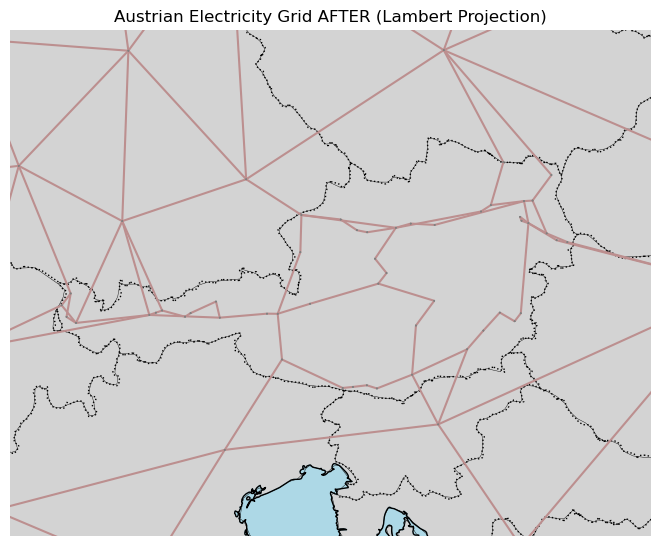

In [10]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# Define Lambert Conformal projection centered over Austria
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)

# Create custom line colors for cross-border lines
#line_colors = n.lines["cross_border"].map({True: "red", False: "blue"})

projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]
figsize = (8.27, 11.69)  # Size of the figure (A4)

# Create the plot with the projection
fig, ax = plt.subplots(
    figsize=figsize,
    subplot_kw={"projection": projection}
)

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

import cartopy.feature as cfeature
# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network
network1.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid AFTER (Lambert Projection)",
    boundaries=[9,18,45,50]
)

/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



(<matplotlib.collections.PatchCollection at 0x76c312dd4fe0>,
 <matplotlib.collections.LineCollection at 0x76c3133d2ab0>)

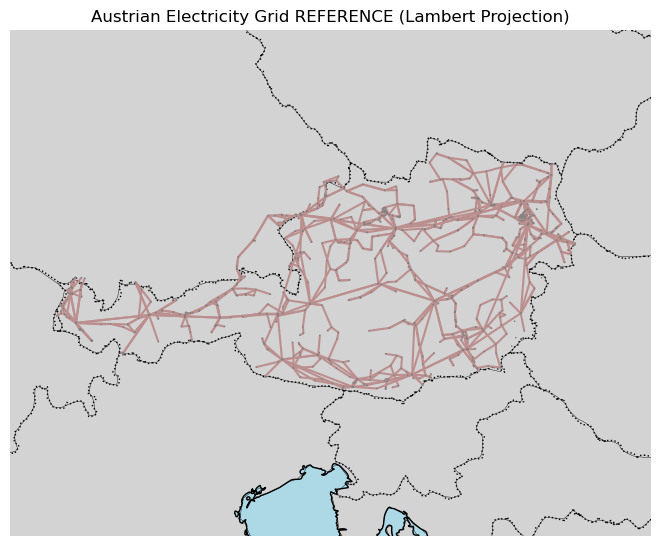

In [11]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# Define Lambert Conformal projection centered over Austria
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)

# Create custom line colors for cross-border lines
#line_colors = n.lines["cross_border"].map({True: "red", False: "blue"})

projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]
figsize = (8.27, 11.69)  # Size of the figure (A4)

# Create the plot with the projection
fig, ax = plt.subplots(
    figsize=figsize,
    subplot_kw={"projection": projection}
)

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

import cartopy.feature as cfeature
# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network
network2.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid REFERENCE (Lambert Projection)",
    boundaries=[9,18,45,50]
)

In [12]:
network2.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,c,v_nom,cross_border
Line,,,,,,,,,,,,,,,,,,,,,
14001.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,110.0,False
14002.0,14001.0,14003.0,,0.3824,0.0557,0.0,0.0,205.196059,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,110.0,False
14003.0,14003.0,14001.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,110.0,False
14004.0,14001.0,14002.0,,0.4035,0.1690,0.0,0.0,89.547027,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,110.0,False
11030.0,11002.0,11005.0,,0.4329,0.2024,0.0,0.0,89.500000,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0483,110.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28065.0,28002.0,28015.0,,0.3106,0.0256,0.0,0.0,777.344402,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,220.0,False
28068.0,28015.0,28050.0,,0.3195,0.0210,0.0,0.0,914.522826,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,220.0,False
39121.0,39003.0,31027.0,,0.2575,0.0151,0.0,0.0,1579.630337,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,380.0,False


In [13]:
network1.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,dc,i_nom,v_nom
Line,,,,,,,,,,,,,,,,,,,,,
0,AL0 0,GR0 0,Al/St 240/40 4-bundle 380.0,90.270060,11.008544,0.0,0.001763,1787.476433,0.0,True,...,0.0,0.0,0.0,0.0,0.000625,0.000076,1787.476697,False,2.58,380.0
1,AL0 0,ME0 0,Al/St 240/40 4-bundle 380.0,28.301610,3.451416,0.0,0.000898,2279.032453,0.0,True,...,0.0,0.0,0.0,0.0,0.000196,0.000024,2743.821625,False,2.58,380.0
10,AT0 12,AT0 16,Al/St 240/40 4-bundle 380.0,33.535940,4.089749,0.0,0.000198,983.112038,0.0,True,...,0.0,0.0,0.0,0.0,0.000232,0.000028,983.112188,False,2.58,380.0
100,DE0 1,DE0 2,Al/St 240/40 4-bundle 380.0,31.086469,3.791033,0.0,0.002191,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000215,0.000026,3396.205456,False,2.58,380.0
101,DE0 1,DE0 3,Al/St 240/40 4-bundle 380.0,3.759843,0.458517,0.0,0.006282,16534.157009,0.0,True,...,0.0,0.0,0.0,0.0,0.000026,0.000003,16534.157944,False,2.58,380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,DE0 0,DE0 2,Al/St 240/40 4-bundle 380.0,7.525794,0.917780,0.0,0.003529,8758.634524,0.0,True,...,0.0,0.0,0.0,0.0,0.000052,0.000006,8758.635312,False,2.58,380.0
96,DE0 0,DE0 4,Al/St 240/40 4-bundle 380.0,71.639076,8.736473,0.0,0.001263,1698.102612,0.0,True,...,0.0,0.0,0.0,0.0,0.000496,0.000061,1925.300026,False,2.58,380.0
97,DE0 0,DE0 5,Al/St 240/40 4-bundle 380.0,3.461817,0.422173,0.0,0.010775,22566.889972,0.0,True,...,0.0,0.0,0.0,0.0,0.000024,0.000003,22566.890958,False,2.58,380.0


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



(<matplotlib.collections.PatchCollection at 0x76c314cae360>,
 <matplotlib.collections.LineCollection at 0x76c314cb0860>)

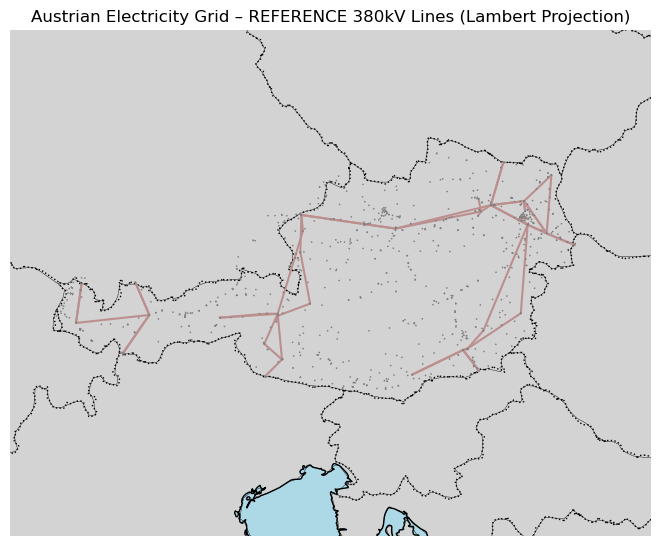

In [14]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

# Filter only 380 kV lines
lines_380kv = network2.lines[network2.lines.v_nom == 380]

# Create a copy of the network with only 380 kV lines
n_380kv = network2.copy()
n_380kv.lines = lines_380kv
# Remove unused components (like buses not connected to any lines)
# n_380kv.remove("lines", n_380kv.lines.index.symmetric_difference(network2.lines.index))
# n_380kv.remove("buses", n_380kv.buses.index.difference(lines_380kv.bus0.append(lines_380kv.bus1).unique()))

# Projection and map setup
projection = ccrs.LambertConformal(central_longitude=13.3, central_latitude=47.5)
projection_params = {"central_longitude": 10, "central_latitude": 50}
extent_lon_range, extent_lat_range = 4, 3
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]

fig, ax = plt.subplots(figsize=(8.27, 11.69), subplot_kw={"projection": projection})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Background map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot only the 380 kV network
n_380kv.plot(
    ax=ax,
    geomap=True,
    projection=projection,
    line_widths=1.5,
    bus_sizes=.0001,
    bus_colors="gray",
    title="Austrian Electricity Grid – REFERENCE 380kV Lines (Lambert Projection)",
    boundaries=[9, 18, 45, 50]
)


/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".

/tmp/ipykernel_2020053/2167443396.py:37: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



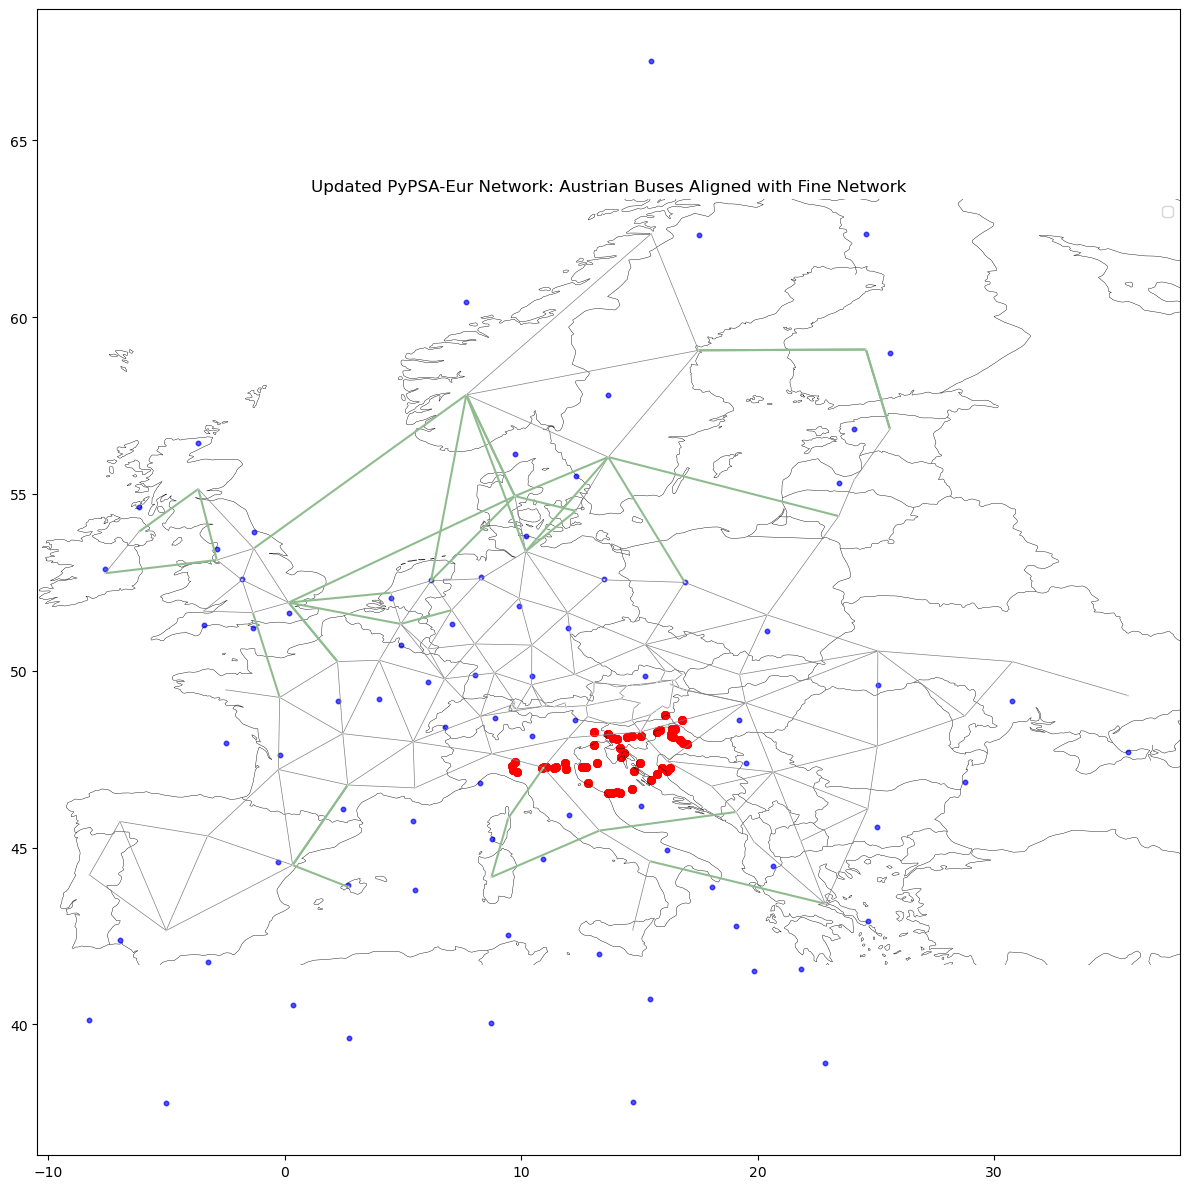

In [15]:
import matplotlib.pyplot as plt

# Create a mask for Austrian buses
is_austria = network1.buses['country'].isin(['AT', 'Austria'])

# Plot base network (lines and buses)
fig, ax = plt.subplots(figsize=(12, 12))
network1.plot(
    line_colors='gray',
    line_widths=0.5,
    bus_sizes=.001,
    bus_colors='lightgray'
)

# Overlay Austrian buses in red
ax.scatter(
    network1.buses.loc[is_austria, 'x'],
    network1.buses.loc[is_austria, 'y'],
    color='red',
    s=30,
    label='Austrian Buses (updated)',
    zorder=3
)

# Overlay foreign buses for contrast
ax.scatter(
    network1.buses.loc[~is_austria, 'x'],
    network1.buses.loc[~is_austria, 'y'],
    color='blue',
    s=10,
    alpha=0.3,
    label='Foreign Buses',
    zorder=2
)

# Final styling
plt.legend()
plt.title("Updated PyPSA-Eur Network: Austrian Buses Aligned with Fine Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()
